In [2]:
import pandas as pd

df = pd.read_csv("Telecom Customer_Churn_Prediction.csv")

print(df.shape)
df.head()

(7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
print(df.info())
print("\nMissing Values:")
print(df.isnull().sum())

print("\nChurn Distribution:")
print(df["Churn"].value_counts())

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [5]:
# Check unique values in TotalCharges
print(df["TotalCharges"].unique()[:20])

# Convert TotalCharges to numeric
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

# Check missing values after conversion
print("Missing values in TotalCharges:", df["TotalCharges"].isnull().sum())

[  29.85 1889.5   108.15 1840.75  151.65  820.5  1949.4   301.9  3046.05
 3487.95  587.45  326.8  5681.1  5036.3  2686.05 7895.15 1022.95 7382.25
  528.35 1862.9 ]
Missing values in TotalCharges: 11


In [6]:
# Fill missing TotalCharges with median
df["TotalCharges"] = df["TotalCharges"].fillna(df["TotalCharges"].median())

# Check again
print(df.isnull().sum().sum())

0


In [7]:
df = df.drop("customerID", axis=1)

print(df.shape)

(7043, 20)


In [8]:
# Target convert karo

# Machine learning model ko Yes/No ki jagah 1/0 chahiye.
df["Churn"] = df["Churn"].map({"Yes": 1, "No": 0})

print(df["Churn"].value_counts())

Churn
0    5174
1    1869
Name: count, dtype: int64


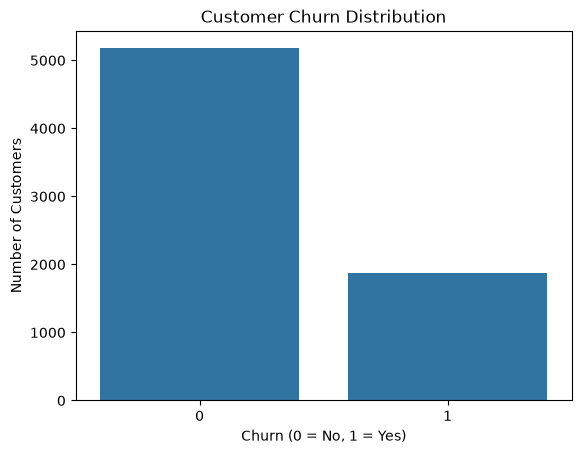

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.countplot(x="Churn", data=df)

plt.title("Customer Churn Distribution")
plt.xlabel("Churn (0 = No, 1 = Yes)")
plt.ylabel("Number of Customers")
plt.show()

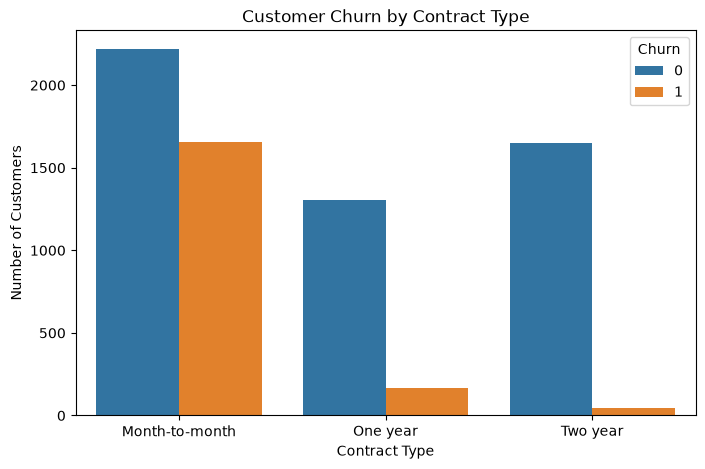

In [10]:
plt.figure(figsize=(8,5))

sns.countplot(x="Contract", hue="Churn", data=df)

plt.title("Customer Churn by Contract Type")
plt.xlabel("Contract Type")
plt.ylabel("Number of Customers")
plt.show()

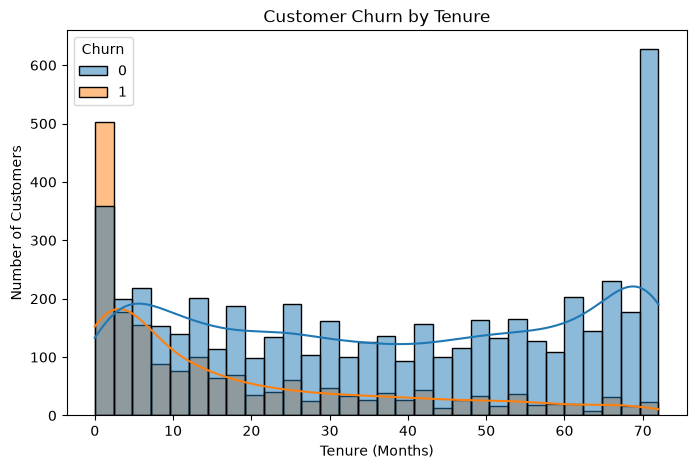

In [11]:
plt.figure(figsize=(8,5))

sns.histplot(
    data=df,
    x="tenure",
    hue="Churn",
    bins=30,
    kde=True
)

plt.title("Customer Churn by Tenure")
plt.xlabel("Tenure (Months)")
plt.ylabel("Number of Customers")
plt.show()

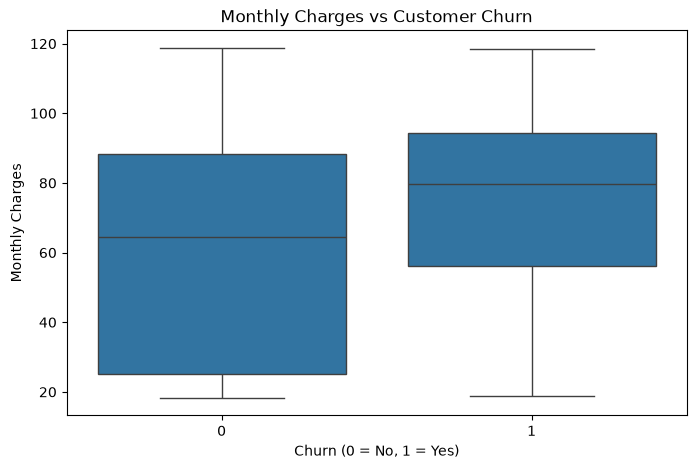

In [12]:
plt.figure(figsize=(8,5))

sns.boxplot(x="Churn", y="MonthlyCharges", data=df)

plt.title("Monthly Charges vs Customer Churn")
plt.xlabel("Churn (0 = No, 1 = Yes)")
plt.ylabel("Monthly Charges")
plt.show()

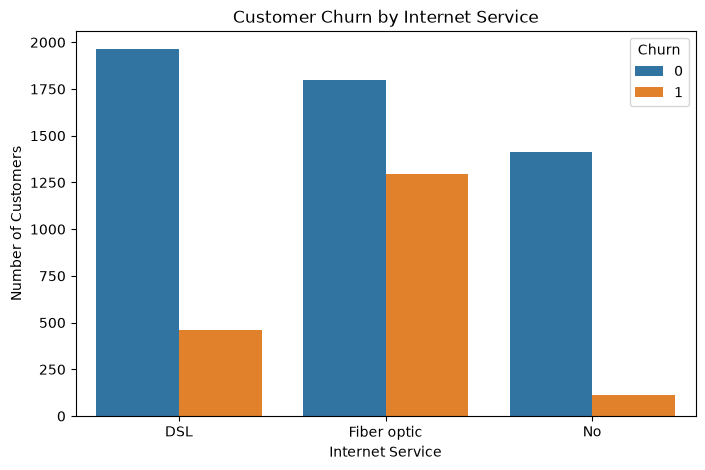

In [13]:
plt.figure(figsize=(8,5))

sns.countplot(x="InternetService", hue="Churn", data=df)

plt.title("Customer Churn by Internet Service")
plt.xlabel("Internet Service")
plt.ylabel("Number of Customers")
plt.show()

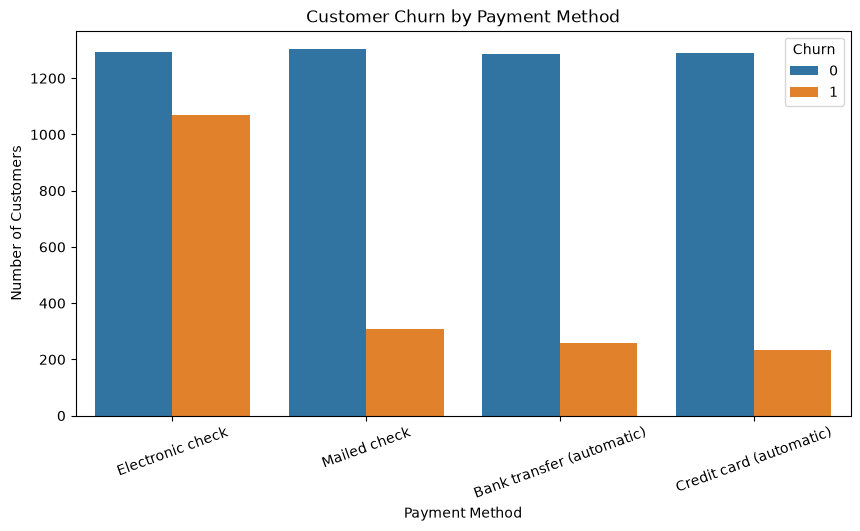

In [14]:
plt.figure(figsize=(10,5))

sns.countplot(
    x="PaymentMethod",
    hue="Churn",
    data=df
)

plt.title("Customer Churn by Payment Method")
plt.xlabel("Payment Method")
plt.ylabel("Number of Customers")
plt.xticks(rotation=20)
plt.show()

Categorical Encoding

Tumhare dataset mein bahut saare columns text format mein hain, jaise:

gender, Partner, InternetService, Contract, PaymentMethod etc.

ML models ko numeric values chahiye, isliye hum One-Hot Encoding use karenge.

1️⃣ Features aur target separate karo

In [15]:
X = df.drop("Churn", axis=1)
y = df["Churn"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (7043, 19)
y shape: (7043,)


In [16]:
#Categorical aur numerical columns identify karo
categorical_cols = X.select_dtypes(include=["object"]).columns
numerical_cols = X.select_dtypes(exclude=["object"]).columns

print("Categorical columns:")
print(list(categorical_cols))

print("\nNumerical columns:")
print(list(numerical_cols))

Categorical columns:
['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']

Numerical columns:
['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']


C:\Users\PRACHI\AppData\Local\Temp\ipykernel_2288\596160830.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = X.select_dtypes(include=["object"]).columns


In [17]:
#One-Hot Encoding
#True/False values dikhengi — that's okay. Scikit-learn models generally handle these, but we'll convert them to integers:

X = pd.get_dummies(X, columns=categorical_cols, drop_first=True)

print("New X shape:", X.shape)
print(X.head())

New X shape: (7043, 30)
   SeniorCitizen  tenure  MonthlyCharges  TotalCharges  gender_Male  \
0              0       1           29.85         29.85        False   
1              0      34           56.95       1889.50         True   
2              0       2           53.85        108.15         True   
3              0      45           42.30       1840.75         True   
4              0       2           70.70        151.65        False   

   Partner_Yes  Dependents_Yes  PhoneService_Yes  \
0         True           False             False   
1        False           False              True   
2        False           False              True   
3        False           False             False   
4        False           False              True   

   MultipleLines_No phone service  MultipleLines_Yes  ...  \
0                            True              False  ...   
1                           False              False  ...   
2                           False              False 

In [18]:
#Important: TotalCharges aur MonthlyCharges numeric rehne chahiye.

X = X.astype(int)

print(X.dtypes.value_counts())

int64    30
Name: count, dtype: int64


In [19]:
# Train-Test Split

# Ab data ko training aur testing mein divide karenge. 
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (5634, 30)
Testing data: (1409, 30)


In [20]:
# SMOTE ⭐

# Ab tumhare project ka important part.

# SMOTE sirf training data par lagayenge, test data par nahi.

# Pehle package check/install:

!pip install imbalanced-learn


   ---------------------------------------- 0/2 [sklearn-compat]
   ---------------------------------------- 0/2 [sklearn-compat]
   ---------------------------------------- 0/2 [sklearn-compat]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn]



[notice] A new release of pip is available: 26.1.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [21]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train,
    y_train
)

print("Before SMOTE:")
print(y_train.value_counts())

print("\nAfter SMOTE:")
print(y_train_smote.value_counts())

Before SMOTE:
Churn
0    4139
1    1495
Name: count, dtype: int64

After SMOTE:
Churn
0    4139
1    4139
Name: count, dtype: int64


In [22]:
#Logistic Regression

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

log_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

log_model.fit(X_train_smote, y_train_smote)

y_pred_log = log_model.predict(X_test)
y_prob_log = log_model.predict_proba(X_test)[:, 1]

print("Logistic Regression")
print(classification_report(y_test, y_pred_log))

print("ROC-AUC:",
      roc_auc_score(y_test, y_prob_log))

Logistic Regression
              precision    recall  f1-score   support

           0       0.88      0.82      0.84      1035
           1       0.57      0.68      0.62       374

    accuracy                           0.78      1409
   macro avg       0.72      0.75      0.73      1409
weighted avg       0.80      0.78      0.79      1409

ROC-AUC: 0.8289441731896974


c:\Users\PRACHI\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [23]:
#Random Forest
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    class_weight=None
)

rf_model.fit(X_train_smote, y_train_smote)

y_pred_rf = rf_model.predict(X_test)
y_prob_rf = rf_model.predict_proba(X_test)[:, 1]

print("Random Forest")
print(classification_report(y_test, y_pred_rf))

print("ROC-AUC:",
      roc_auc_score(y_test, y_prob_rf))

Random Forest
              precision    recall  f1-score   support

           0       0.85      0.83      0.84      1035
           1       0.56      0.61      0.58       374

    accuracy                           0.77      1409
   macro avg       0.71      0.72      0.71      1409
weighted avg       0.78      0.77      0.77      1409

ROC-AUC: 0.8183264873801959


In [24]:
# XGBoost 🚀

# First install it if needed:
!pip install xgboost

   ---------------------------------------- 0.0/48.9 MB ? eta -:--:--
   ---------------------------------------- 0.0/48.9 MB ? eta -:--:--
   ---------------------------------------- 0.3/48.9 MB ? eta -:--:--
    --------------------------------------- 0.8/48.9 MB 2.1 MB/s eta 0:00:24
   - -------------------------------------- 1.3/48.9 MB 2.2 MB/s eta 0:00:22
   - -------------------------------------- 1.8/48.9 MB 2.4 MB/s eta 0:00:20
   -- ------------------------------------- 2.6/48.9 MB 2.7 MB/s eta 0:00:18
   -- ------------------------------------- 3.7/48.9 MB 3.1 MB/s eta 0:00:15
   --- ------------------------------------ 4.7/48.9 MB 3.4 MB/s eta 0:00:13
   ---- ----------------------------------- 6.0/48.9 MB 3.8 MB/s eta 0:00:12
   ----- ---------------------------------- 7.3/48.9 MB 4.2 MB/s eta 0:00:10
   ------- -------------------------------- 9.4/48.9 MB 4.7 MB/s eta 0:00:09
   --------- ------------------------------ 11.8/48.9 MB 5.4 MB/s eta 0:00:07
   ------------ ---


[notice] A new release of pip is available: 26.1.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [25]:
from xgboost import XGBClassifier

xgb_model = XGBClassifier(
    n_estimators=200,
    max_depth=5,
    learning_rate=0.05,
    random_state=42,
    eval_metric="logloss"
)

xgb_model.fit(X_train_smote, y_train_smote)

y_pred_xgb = xgb_model.predict(X_test)
y_prob_xgb = xgb_model.predict_proba(X_test)[:, 1]

print("XGBoost")
print(classification_report(y_test, y_pred_xgb))

print("ROC-AUC:",
      roc_auc_score(y_test, y_prob_xgb))

XGBoost
              precision    recall  f1-score   support

           0       0.86      0.81      0.84      1035
           1       0.56      0.64      0.60       374

    accuracy                           0.77      1409
   macro avg       0.71      0.73      0.72      1409
weighted avg       0.78      0.77      0.77      1409

ROC-AUC: 0.8339275103980986


In [26]:
# Model Comparison ⭐

# Ab teeno models ke results ek table mein:
results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest",
        "XGBoost"
    ],
    "Accuracy": [
        accuracy_score(y_test, y_pred_log),
        accuracy_score(y_test, y_pred_rf),
        accuracy_score(y_test, y_pred_xgb)
    ],
    "Precision": [
        precision_score(y_test, y_pred_log),
        precision_score(y_test, y_pred_rf),
        precision_score(y_test, y_pred_xgb)
    ],
    "Recall": [
        recall_score(y_test, y_pred_log),
        recall_score(y_test, y_pred_rf),
        recall_score(y_test, y_pred_xgb)
    ],
    "F1 Score": [
        f1_score(y_test, y_pred_log),
        f1_score(y_test, y_pred_rf),
        f1_score(y_test, y_pred_xgb)
    ],
    "ROC-AUC": [
        roc_auc_score(y_test, y_prob_log),
        roc_auc_score(y_test, y_prob_rf),
        roc_auc_score(y_test, y_prob_xgb)
    ]
})

results.round(4)

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.7800,0.5721,0.6791,0.6210,0.8289
1,Random Forest,0.7693,0.5602,0.6096,0.5839,0.8183
2,XGBoost,0.7686,0.5556,0.6417,0.5955,0.8339


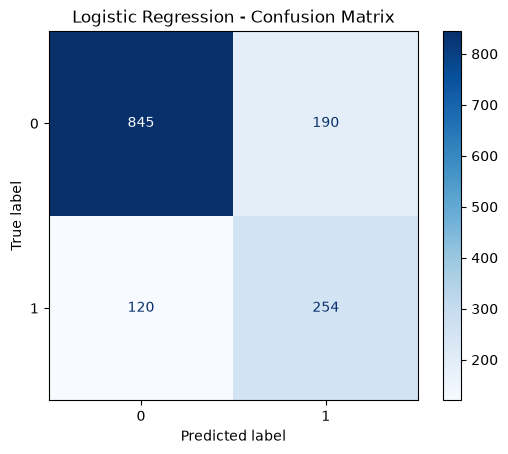

In [27]:
#Confusion Matrix

#Pehle Logistic Regression
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_log,
    cmap="Blues"
)

plt.title("Logistic Regression - Confusion Matrix")
plt.show()

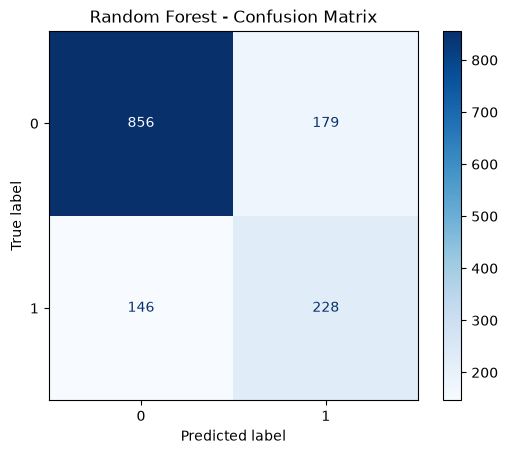

In [28]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_rf,
    cmap="Blues"
)

plt.title("Random Forest - Confusion Matrix")
plt.show()

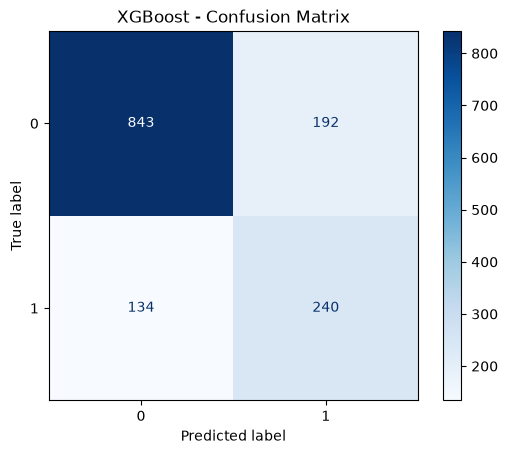

In [29]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_xgb,
    cmap="Blues"
)

plt.title("XGBoost - Confusion Matrix")
plt.show()

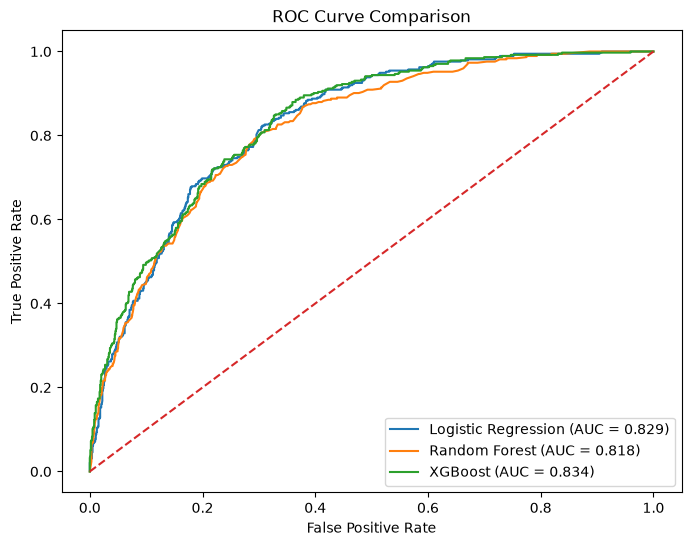

In [30]:
#ROC Curve

#Teeno models ko ek graph mein compare karenge:

from sklearn.metrics import roc_curve

fpr_log, tpr_log, _ = roc_curve(y_test, y_prob_log)
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, y_prob_xgb)

plt.figure(figsize=(8,6))

plt.plot(
    fpr_log,
    tpr_log,
    label=f"Logistic Regression (AUC = {roc_auc_score(y_test, y_prob_log):.3f})"
)

plt.plot(
    fpr_rf,
    tpr_rf,
    label=f"Random Forest (AUC = {roc_auc_score(y_test, y_prob_rf):.3f})"
)

plt.plot(
    fpr_xgb,
    tpr_xgb,
    label=f"XGBoost (AUC = {roc_auc_score(y_test, y_prob_xgb):.3f})"
)

plt.plot([0, 1], [0, 1], "--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.show()

In [31]:
# Feature Importance ⭐

# Ab sabse interesting part:

# Which factors are associated with customer churn?

# Random Forest se start karte hain:

feature_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": rf_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

print(feature_importance.head(15))

                                  Feature  Importance
3                            TotalCharges    0.141216
1                                  tenure    0.139663
2                          MonthlyCharges    0.103791
25                      Contract_Two year    0.066245
13                     OnlineSecurity_Yes    0.059657
19                        TechSupport_Yes    0.049375
24                      Contract_One year    0.046131
6                          Dependents_Yes    0.036841
10            InternetService_Fiber optic    0.029356
15                       OnlineBackup_Yes    0.028510
5                             Partner_Yes    0.025076
27  PaymentMethod_Credit card (automatic)    0.024197
4                             gender_Male    0.023909
17                   DeviceProtection_Yes    0.021374
26                   PaperlessBilling_Yes    0.020535


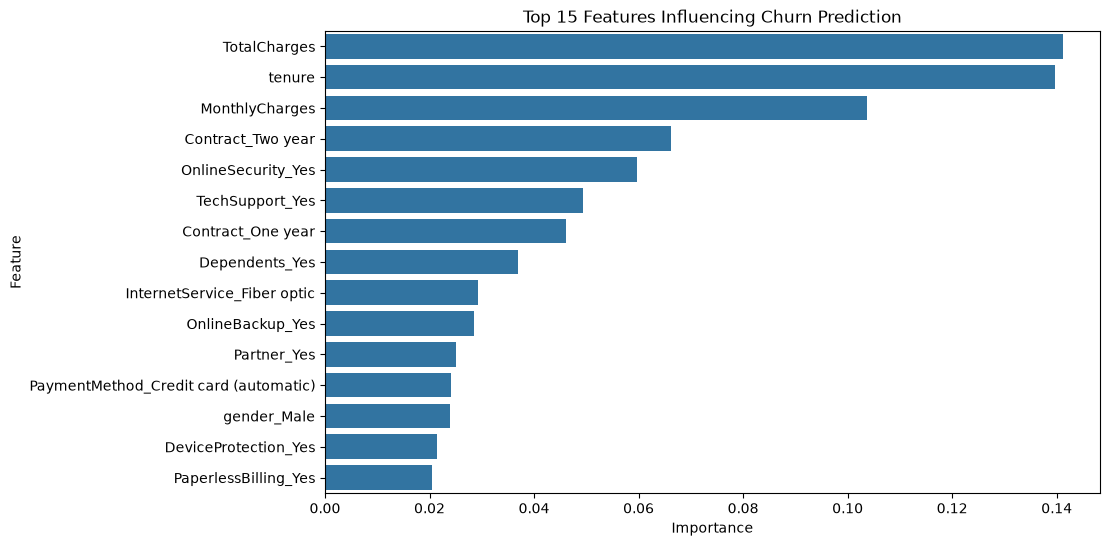

In [32]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=feature_importance.head(15),
    x="Importance",
    y="Feature"
)

plt.title("Top 15 Features Influencing Churn Prediction")
plt.xlabel("Importance")
plt.ylabel("Feature")

plt.show()

In [ ]:
# Final Model Save Karo

# Ab XGBoost model ko save karenge, taaki baad mein Streamlit app mein directly use kar sakein.
#Tumhare project folder mein 2 files create hongi:

import joblib

joblib.dump(xgb_model, "customer_churn_xgboost.pkl")

joblib.dump(list(X.columns), "model_features.pkl")

print("Model saved successfully!")

Model saved successfully!


In [34]:
# Test the Model with an Existing Customer

# Pehle ek existing customer ko test karke dekhte hain.

sample_customer = X_test.iloc[[0]]

prediction = xgb_model.predict(sample_customer)[0]
probability = xgb_model.predict_proba(sample_customer)[0][1]

print("Prediction:", "Will Churn" if prediction == 1 else "Will Not Churn")
print("Churn Probability:", round(probability * 100, 2), "%")

Prediction: Will Not Churn
Churn Probability: 1.4 %


In [35]:
# Create a Prediction Function

# Ab ek reusable function banate hain:
def predict_churn(customer_data):
    
    customer_df = pd.DataFrame([customer_data])
    
    # Convert categorical variables
    customer_df = pd.get_dummies(customer_df)
    
    # Match training features
    customer_df = customer_df.reindex(
        columns=X.columns,
        fill_value=0
    )
    
    prediction = xgb_model.predict(customer_df)[0]
    probability = xgb_model.predict_proba(customer_df)[0][1]
    
    result = "Will Churn" if prediction == 1 else "Will Not Churn"
    
    return result, probability

In [36]:
# Demo Customer

# For example:

customer = {
    "gender": "Female",
    "SeniorCitizen": 0,
    "Partner": "Yes",
    "Dependents": "No",
    "tenure": 5,
    "PhoneService": "Yes",
    "MultipleLines": "No",
    "InternetService": "Fiber optic",
    "OnlineSecurity": "No",
    "OnlineBackup": "No",
    "DeviceProtection": "No",
    "TechSupport": "No",
    "StreamingTV": "No",
    "StreamingMovies": "No",
    "Contract": "Month-to-month",
    "PaperlessBilling": "Yes",
    "PaymentMethod": "Electronic check",
    "MonthlyCharges": 80.50,
    "TotalCharges": 402.50
}

result, probability = predict_churn(customer)

print("Prediction:", result)
print("Churn Probability:", round(probability * 100, 2), "%")

Prediction: Will Churn
Churn Probability: 93.22 %


In [37]:
# professional Streamlit web app — this will make the project much stronger for your resume.

#  Install Streamlit

!pip install streamlit

   ---------------------------------------- 0.0/10.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/10.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/10.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/10.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/10.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/10.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/10.1 MB ? eta -:--:--
   - -------------------------------------- 0.3/10.1 MB ? eta -:--:--
   - -------------------------------------- 0.3/10.1 MB ? eta -:--:--
   - -------------------------------------- 0.3/10.1 MB ? eta -:--:--
   - -------------------------------------- 0.3/10.1 MB ? eta -:--:--
   - -------------------------------------- 0.3/10.1 MB ? eta -:--:--
   - -------------------------------------- 0.3/10.1 MB ? eta -:--:--
   -- ------------------------------------- 0.5/10.1 MB 214.2 kB/s eta 0:00:45
   -- -----


[notice] A new release of pip is available: 26.1.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip
